# Fruit Grading — Comparative Experiments

Notebook ini menambahkan pipeline eksperimen pembanding tanpa mengubah pipeline utama:

- **Model A — Baseline CNN**: CNN kecil sebagai baseline.
- **Model B — Improved CNN**: BatchNorm, Dropout, EarlyStopping, ReduceLROnPlateau, augmentasi lebih kuat.
- **Model C — Transfer Learning**: MobileNetV2 dengan freeze lalu fine-tuning.
- **Model D — Tanpa KMeans**: memakai manual/original labels jika file label manual tersedia.
- **Model E — Alternative Clustering**: Gaussian Mixture Model (GMM), lalu CNN sederhana dilatih dari label cluster alternatif.

Prinsip komparasi:

- split train/validation/test dibuat sekali dan dipakai ulang;
- seed sama;
- metric sama;
- preprocessing gambar konsisten, kecuali transfer learning memakai preprocessing bawaan MobileNetV2;
- semua output eksperimen disimpan di `output/comparative_experiments/`.

In [2]:
# Dependency install cell. Jalankan cell ini sekali jika muncul ModuleNotFoundError.
# Setelah install selesai, restart  kernel lalu jalankan notebook dari awal.
%pip install tensorflow scikit-learn pandas matplotlib seaborn opencv-python -q

Note: you may need to restart the kernel to use updated packages.


## 1. Imports dan Konfigurasi

In [3]:
import os
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.mixture import GaussianMixture

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

LABELED_CSV = Path("output/labeled_dataset.csv")
FEATURES_CSV = Path("output/kmeans_features.csv")
DATASET_ROOT_CANDIDATES = [
    Path("dataset"),
    Path("/Users/theofilius/Downloads/fruit-grading-model-main/dataset"),
]
OUTPUT_DIR = Path("output/comparative_experiments")
PLOTS_DIR = OUTPUT_DIR / "plots"
MODELS_DIR = OUTPUT_DIR / "models"
REPORTS_DIR = OUTPUT_DIR / "reports"

for directory in [OUTPUT_DIR, PLOTS_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
MAX_EPOCHS = 20
TRANSFER_FROZEN_EPOCHS = 10
TRANSFER_FINE_TUNE_EPOCHS = 10
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

FRUITS = ["apple", "orange", "banana"]
GRADES = ["A", "B", "C"]
CLASS_NAMES = [f"{fruit}_{grade}" for fruit in FRUITS for grade in GRADES]
N_CLASSES = len(CLASS_NAMES)

print(f"TensorFlow: {tf.__version__}")
print(f"Output dir: {OUTPUT_DIR.resolve()}")

Matplotlib is building the font cache; this may take a moment.
2026-05-10 23:55:30.790921: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.16.2
Output dir: /Users/theofilius/Downloads/fruit-grading-model-main/output/comparative_experiments


## 2. Helper Dataset dan Split Fair

In [4]:
def resolve_image_path(path_value):
    """Return an existing path, trying Windows, POSIX, and known dataset roots."""
    raw = str(path_value)
    normalized = raw.replace("\\", os.sep).replace("/", os.sep)
    candidates = [Path(raw), Path(normalized)]

    # If the CSV starts with dataset/..., try replacing that root with configured roots.
    parts = Path(normalized).parts
    if parts and parts[0] == "dataset":
        relative_inside_dataset = Path(*parts[1:])
        for root in DATASET_ROOT_CANDIDATES:
            candidates.append(root / relative_inside_dataset)

    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return str(candidates[1])


def load_labeled_dataframe(csv_path=LABELED_CSV):
    if not csv_path.exists():
        raise FileNotFoundError(
            f"{csv_path} tidak ditemukan. Jalankan notebook Step 1 KMeans lebih dulu."
        )

    df = pd.read_csv(csv_path)
    required = {"image_path", "fruit", "grade", "label"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Kolom wajib hilang dari {csv_path}: {sorted(missing)}")

    df = df.copy()
    df["image_path_original"] = df["image_path"]
    df["image_path"] = df["image_path"].apply(resolve_image_path)
    df["exists"] = df["image_path"].apply(lambda p: Path(p).exists())

    n_missing = int((~df["exists"]).sum())
    if n_missing:
        print(f"WARNING: {n_missing} path gambar tidak ditemukan dan akan dibuang.")
        print("Pastikan folder dataset/ tersedia jika ingin menjalankan training.")
        df = df[df["exists"]].copy()

    df = df[df["label"].isin(CLASS_NAMES)].copy()
    if df.empty:
        example_path = pd.read_csv(csv_path)["image_path"].iloc[0]
        roots = "\n".join(f"  - {root.resolve()} | exists={root.exists()}" for root in DATASET_ROOT_CANDIDATES)
        raise ValueError(
            "Tidak ada gambar valid setelah path check dan filter label.\n\n"
            "CSV label sudah ada, tetapi file gambar asli tidak ditemukan.\n"
            f"Contoh path di CSV: {example_path}\n\n"
            "Solusi:\n"
            "1. Pastikan dataset Kaggle sudah diekstrak ke folder `dataset/` di root project ini, atau\n"
            "2. Edit DATASET_ROOT_CANDIDATES di cell konfigurasi agar menunjuk ke lokasi dataset yang benar, lalu restart kernel dan jalankan ulang.\n\n"
            f"Dataset roots yang dicek sekarang:\n{roots}"
        )

    return df.reset_index(drop=True)


def make_fixed_split(df):
    """Create one split assignment reused by every experiment."""
    df_train, df_temp = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["label"],
        random_state=SEED,
    )
    val_frac = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    df_val, df_test = train_test_split(
        df_temp,
        test_size=(1 - val_frac),
        stratify=df_temp["label"],
        random_state=SEED,
    )

    split_df = pd.concat(
        [
            df_train.assign(split="train"),
            df_val.assign(split="val"),
            df_test.assign(split="test"),
        ],
        ignore_index=True,
    )
    split_df.to_csv(OUTPUT_DIR / "fixed_split_kmeans_reference.csv", index=False)
    return split_df


df_kmeans = load_labeled_dataframe()
split_df = make_fixed_split(df_kmeans)

print(f"Total valid images: {len(split_df):,}")
print(split_df["split"].value_counts().sort_index())
print("\nLabel distribution by split:")
display(pd.crosstab(split_df["label"], split_df["split"]))

Total valid images: 5,904
split
test      886
train    4132
val       886
Name: count, dtype: int64

Label distribution by split:


split,test,train,val
label,,,
apple_A,109,511,110
apple_B,100,470,101
apple_C,103,481,103
banana_A,84,390,84
banana_B,165,766,164
banana_C,47,216,46
orange_A,84,391,83
orange_B,176,821,176
orange_C,18,86,19


## 3. tf.data Pipeline

In [5]:
def decode_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_augmentation(strength="none"):
    if strength == "none":
        return keras.Sequential(name="no_augmentation")
    if strength == "light":
        return keras.Sequential(
            [
                layers.RandomFlip("horizontal", seed=SEED),
                layers.RandomRotation(0.06, seed=SEED),
                layers.RandomBrightness(0.10, seed=SEED),
            ],
            name="light_augmentation",
        )
    if strength == "strong":
        return keras.Sequential(
            [
                layers.RandomFlip("horizontal", seed=SEED),
                layers.RandomRotation(0.10, seed=SEED),
                layers.RandomZoom(0.12, seed=SEED),
                layers.RandomContrast(0.20, seed=SEED),
                layers.RandomBrightness(0.20, seed=SEED),
            ],
            name="strong_augmentation",
        )
    raise ValueError(f"Unknown augmentation strength: {strength}")


def make_tf_dataset(df, label_encoder, shuffle=False):
    paths = df["image_path"].astype(str).values
    labels = label_encoder.transform(df["label"].values)
    y = tf.keras.utils.to_categorical(labels, num_classes=len(label_encoder.classes_))

    ds = tf.data.Dataset.from_tensor_slices((paths, y))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


def split_for_label_source(label_df, class_names=CLASS_NAMES):
    """Apply the reference image split to another label source."""
    keep_cols = ["image_path", "split"]
    ref = split_df[keep_cols].drop_duplicates()

    candidate = label_df.copy()
    candidate["image_path"] = candidate["image_path"].apply(resolve_image_path)
    candidate = candidate[candidate["image_path"].apply(lambda p: Path(p).exists())].copy()
    candidate = candidate[candidate["label"].isin(class_names)].copy()

    merged = candidate.merge(ref, on="image_path", how="inner")
    if merged.empty:
        raise ValueError("Label source tidak overlap dengan fixed split reference.")

    return (
        merged[merged["split"] == "train"].reset_index(drop=True),
        merged[merged["split"] == "val"].reset_index(drop=True),
        merged[merged["split"] == "test"].reset_index(drop=True),
    )

## 4. Model Builder

In [6]:
def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model


def build_baseline_cnn(num_classes=N_CLASSES, augmentation="light"):
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = make_augmentation(augmentation)(inputs)
    x = layers.Rescaling(1.0 / 255.0)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return compile_model(keras.Model(inputs, outputs, name="baseline_cnn"), 1e-3)


def build_improved_cnn(num_classes=N_CLASSES, augmentation="strong"):
    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = make_augmentation(augmentation)(inputs)
    x = layers.Rescaling(1.0 / 255.0)(x)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.20)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.45)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return compile_model(keras.Model(inputs, outputs, name="improved_cnn"), 8e-4)


def build_transfer_model(num_classes=N_CLASSES, train_base=False, learning_rate=1e-3):
    base = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMAGE_SIZE, 3),
    )
    base.trainable = train_base

    inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
    x = make_augmentation("strong")(inputs)
    x = mobilenet_preprocess(x)
    x = base(x, training=False if not train_base else True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.45)(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")
    return compile_model(model, learning_rate), base


def get_callbacks(experiment_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            MODELS_DIR / f"{experiment_name}.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

## 5. Evaluasi Standar

In [7]:
def plot_history(history_dict, experiment_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    epochs = range(1, len(history_dict["accuracy"]) + 1)

    axes[0].plot(epochs, history_dict["accuracy"], label="Train Accuracy")
    axes[0].plot(epochs, history_dict["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{experiment_name} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history_dict["loss"], label="Train Loss")
    axes[1].plot(epochs, history_dict["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{experiment_name} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    path = PLOTS_DIR / f"{experiment_name}_training_curves.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path


def plot_confusion_matrix(y_true, y_pred, class_names, experiment_name):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Counts", "Normalized"],
    ):
        sns.heatmap(
            data,
            annot=True,
            fmt=fmt,
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            ax=ax,
            linewidths=0.5,
            linecolor="white",
        )
        ax.set_title(f"{experiment_name} - Confusion Matrix ({title})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.tick_params(axis="x", rotation=35)
        ax.tick_params(axis="y", rotation=0)

    fig.tight_layout()
    path = PLOTS_DIR / f"{experiment_name}_confusion_matrix.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path


def overfitting_summary(history_dict):
    best_epoch = int(np.argmax(history_dict["val_accuracy"]))
    train_acc = float(history_dict["accuracy"][best_epoch])
    val_acc = float(history_dict["val_accuracy"][best_epoch])
    train_loss = float(history_dict["loss"][best_epoch])
    val_loss = float(history_dict["val_loss"][best_epoch])
    acc_gap = train_acc - val_acc
    loss_gap = val_loss - train_loss

    if acc_gap > 0.15 and loss_gap > 0.25:
        status = "High overfitting"
    elif acc_gap > 0.08:
        status = "Moderate overfitting"
    else:
        status = "Stable / low gap"

    return {
        "best_epoch": best_epoch + 1,
        "best_train_accuracy": train_acc,
        "best_val_accuracy": val_acc,
        "accuracy_gap": acc_gap,
        "loss_gap": loss_gap,
        "overfitting_status": status,
    }


def evaluate_model(model, test_ds, y_true, class_names, experiment_name, history_dict):
    probabilities = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
    )
    (REPORTS_DIR / f"{experiment_name}_classification_report.txt").write_text(report)

    curves_path = plot_history(history_dict, experiment_name)
    cm_path = plot_confusion_matrix(y_true, y_pred, class_names, experiment_name)
    overfit = overfitting_summary(history_dict)

    result = {
        "experiment": experiment_name,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "training_curves": str(curves_path),
        "confusion_matrix": str(cm_path),
        **overfit,
    }

    print(report)
    return result


def merge_histories(*histories):
    merged = {}
    for history in histories:
        for key, values in history.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

## 6. Runner Eksperimen

In [8]:
@dataclass
class ExperimentSpec:
    name: str
    label_source: str
    build_kind: str
    notes: str


def train_standard_experiment(spec, label_df, build_fn, class_names=CLASS_NAMES):
    print(f"\n{'='*70}\nRunning {spec.name}: {spec.notes}\n{'='*70}")
    train_df, val_df, test_df = split_for_label_source(label_df, class_names)

    encoder = LabelEncoder()
    encoder.fit(class_names)

    train_ds = make_tf_dataset(train_df, encoder, shuffle=True)
    val_ds = make_tf_dataset(val_df, encoder, shuffle=False)
    test_ds = make_tf_dataset(test_df, encoder, shuffle=False)
    y_test = encoder.transform(test_df["label"].values)

    model = build_fn(len(class_names))
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        callbacks=get_callbacks(spec.name),
        verbose=1,
    )

    result = evaluate_model(
        model,
        test_ds,
        y_test,
        class_names,
        spec.name,
        history.history,
    )
    result.update(
        {
            "label_source": spec.label_source,
            "model_type": spec.build_kind,
            "notes": spec.notes,
            "n_train": len(train_df),
            "n_val": len(val_df),
            "n_test": len(test_df),
        }
    )
    return result


def train_transfer_experiment(label_df, class_names=CLASS_NAMES):
    spec = ExperimentSpec(
        name="model_c_transfer_mobilenetv2_kmeans",
        label_source="KMeans pseudo-label",
        build_kind="MobileNetV2 transfer learning",
        notes="Frozen ImageNet backbone followed by top-layer fine tuning.",
    )
    print(f"\n{'='*70}\nRunning {spec.name}: {spec.notes}\n{'='*70}")

    train_df, val_df, test_df = split_for_label_source(label_df, class_names)
    encoder = LabelEncoder()
    encoder.fit(class_names)
    train_ds = make_tf_dataset(train_df, encoder, shuffle=True)
    val_ds = make_tf_dataset(val_df, encoder, shuffle=False)
    test_ds = make_tf_dataset(test_df, encoder, shuffle=False)
    y_test = encoder.transform(test_df["label"].values)

    model, base = build_transfer_model(len(class_names), train_base=False, learning_rate=1e-3)
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=TRANSFER_FROZEN_EPOCHS,
        callbacks=get_callbacks(spec.name + "_frozen"),
        verbose=1,
    )

    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False
    compile_model(model, learning_rate=1e-5)

    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=TRANSFER_FINE_TUNE_EPOCHS,
        callbacks=get_callbacks(spec.name + "_finetune"),
        verbose=1,
    )

    history = merge_histories(history1, history2)
    model.save(MODELS_DIR / f"{spec.name}.keras")

    result = evaluate_model(model, test_ds, y_test, class_names, spec.name, history)
    result.update(
        {
            "label_source": spec.label_source,
            "model_type": spec.build_kind,
            "notes": spec.notes,
            "n_train": len(train_df),
            "n_val": len(val_df),
            "n_test": len(test_df),
        }
    )
    return result

## 7. Model E — Alternative Clustering dengan GMM

In [9]:
QUALITY_FEATURE_WEIGHTS = {
    "val_mean": 0.25,
    "sat_mean": 0.20,
    "color_uniformity": 0.20,
    "texture_homogeneity": 0.15,
    "blemish_ratio": -0.10,
    "edge_density": -0.10,
}

APPLE_EXCLUDED_CLUSTER_FEATURES = {"hue_mean", "r_mean", "g_mean", "b_mean"}


def quality_score(center, feature_names):
    idx = {name: i for i, name in enumerate(feature_names)}
    score = 0.0
    if "val_mean" in idx:
        score += 0.25 * center[idx["val_mean"]] / 255.0
    if "sat_mean" in idx:
        score += 0.20 * center[idx["sat_mean"]] / 255.0
    if "color_uniformity" in idx:
        score += 0.20 * center[idx["color_uniformity"]] / 10.0
    if "texture_homogeneity" in idx:
        score += 0.15 * center[idx["texture_homogeneity"]]
    if "blemish_ratio" in idx:
        score -= 0.10 * center[idx["blemish_ratio"]]
    if "edge_density" in idx:
        score -= 0.10 * center[idx["edge_density"]]
    return score


def build_gmm_label_dataframe():
    if not FEATURES_CSV.exists():
        raise FileNotFoundError(
            f"{FEATURES_CSV} tidak ditemukan. Jalankan Step 1 KMeans untuk membuat fitur lebih dulu."
        )

    features = pd.read_csv(FEATURES_CSV)
    features = features.copy()
    features["image_path"] = features["image_path"].apply(resolve_image_path)
    features = features[features["image_path"].apply(lambda p: Path(p).exists())].copy()

    records = []
    cluster_summary = []
    for fruit, fruit_df in features.groupby("fruit"):
        feature_cols = [c for c in fruit_df.columns if c not in ["image_path", "fruit"]]
        if fruit == "apple":
            feature_cols = [c for c in feature_cols if c not in APPLE_EXCLUDED_CLUSTER_FEATURES]

        X = fruit_df[feature_cols].values
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=SEED)
        clusters = gmm.fit_predict(X_scaled)

        # Convert GMM centers back to original feature scale before quality scoring.
        centers_original = scaler.inverse_transform(gmm.means_)
        scores = [quality_score(center, feature_cols) for center in centers_original]
        ranked_clusters = np.argsort(scores)[::-1]
        grade_map = {int(cluster_id): GRADES[rank] for rank, cluster_id in enumerate(ranked_clusters)}

        for cluster_id, count in zip(*np.unique(clusters, return_counts=True)):
            cluster_summary.append(
                {
                    "fruit": fruit,
                    "cluster_id": int(cluster_id),
                    "grade": grade_map[int(cluster_id)],
                    "count": int(count),
                    "quality_score": float(scores[int(cluster_id)]),
                }
            )

        for row_idx, (_, row) in enumerate(fruit_df.iterrows()):
            cluster_id = int(clusters[row_idx])
            grade = grade_map[cluster_id]
            records.append(
                {
                    "image_path": row["image_path"],
                    "fruit": fruit,
                    "cluster_id": cluster_id,
                    "grade": grade,
                    "label": f"{fruit}_{grade}",
                }
            )

    alt_df = pd.DataFrame(records)
    summary_df = pd.DataFrame(cluster_summary)
    alt_df.to_csv(OUTPUT_DIR / "gmm_labeled_dataset.csv", index=False)
    summary_df.to_csv(OUTPUT_DIR / "gmm_cluster_summary.csv", index=False)
    display(summary_df.sort_values(["fruit", "grade"]))
    return alt_df


df_gmm = build_gmm_label_dataframe()
print(f"GMM labeled records: {len(df_gmm):,}")

,fruit,cluster_id,grade,count,quality_score
1,apple,1,A,681,0.316708
0,apple,0,B,674,0.274961
2,apple,2,C,733,0.266460
4,banana,1,A,534,0.361241
5,banana,2,B,1028,0.295662
3,banana,0,C,400,0.291292
7,orange,1,A,564,0.356434
6,orange,0,B,1144,0.304721
8,orange,2,C,146,0.297953


GMM labeled records: 5,904


## 8. Model D — Manual/Original Labels Jika Tersedia

In [10]:
MANUAL_LABEL_CANDIDATES = [
    Path("output/manual_labeled_dataset.csv"),
    Path("output/original_labeled_dataset.csv"),
    Path("manual_labeled_dataset.csv"),
    Path("original_labeled_dataset.csv"),
]


def load_manual_label_dataframe():
    for path in MANUAL_LABEL_CANDIDATES:
        if path.exists():
            df = pd.read_csv(path)
            required = {"image_path", "fruit", "grade", "label"}
            missing = required - set(df.columns)
            if missing:
                raise ValueError(f"{path} ada, tetapi kolom ini hilang: {sorted(missing)}")
            df = df.copy()
            df["image_path"] = df["image_path"].apply(resolve_image_path)
            df = df[df["image_path"].apply(lambda p: Path(p).exists())].copy()
            print(f"Manual/original label file ditemukan: {path}")
            return df.reset_index(drop=True), str(path)

    print("Manual/original label file tidak ditemukan.")
    print("Model D akan dilewati. Buat salah satu file berikut jika ingin membandingkan tanpa KMeans:")
    for path in MANUAL_LABEL_CANDIDATES:
        print(f"  - {path}")
    return None, None


df_manual, manual_label_path = load_manual_label_dataframe()

Manual/original label file tidak ditemukan.
Model D akan dilewati. Buat salah satu file berikut jika ingin membandingkan tanpa KMeans:
  - output/manual_labeled_dataset.csv
  - output/original_labeled_dataset.csv
  - manual_labeled_dataset.csv
  - original_labeled_dataset.csv


## 9. Jalankan Semua Eksperimen


Running model_a_baseline_cnn_kmeans: CNN sederhana dengan augmentasi ringan sebagai baseline.
Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3157 - loss: 1.8065 - precision: 0.4761 - recall: 0.0865
Epoch 1: val_loss improved from None to 0.63411, saving model to output/comparative_experiments/models/model_a_baseline_cnn_kmeans.keras

Epoch 1: finished saving model to output/comparative_experiments/models/model_a_baseline_cnn_kmeans.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 417s 3s/step - accuracy: 0.4872 - loss: 1.4012 - precision: 0.7291 - recall: 0.2749 - val_accuracy: 0.8138 - val_loss: 0.6341 - val_precision: 0.8781 - val_recall: 0.7483 - learning_rate: 0.0010
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7850 - loss: 0.6495 - precision: 0.8216 - recall: 0.7254
Epoch 2: val_loss improved from 0.63411 to 0.40374, saving model to output/comparative_experiments/models/model_a_baseline_cnn_kmeans.keras

Epoch 2: finished saving model to output/comparative

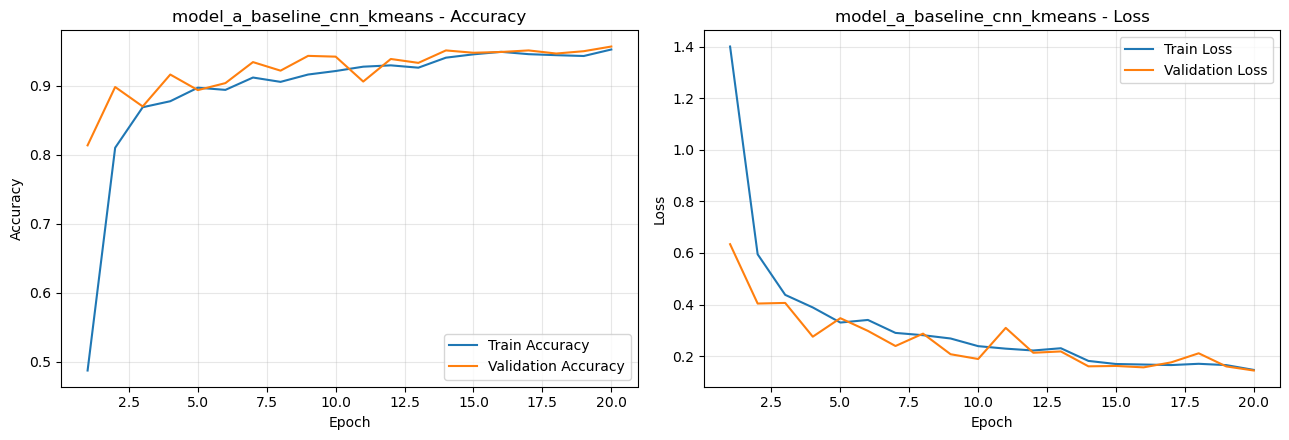

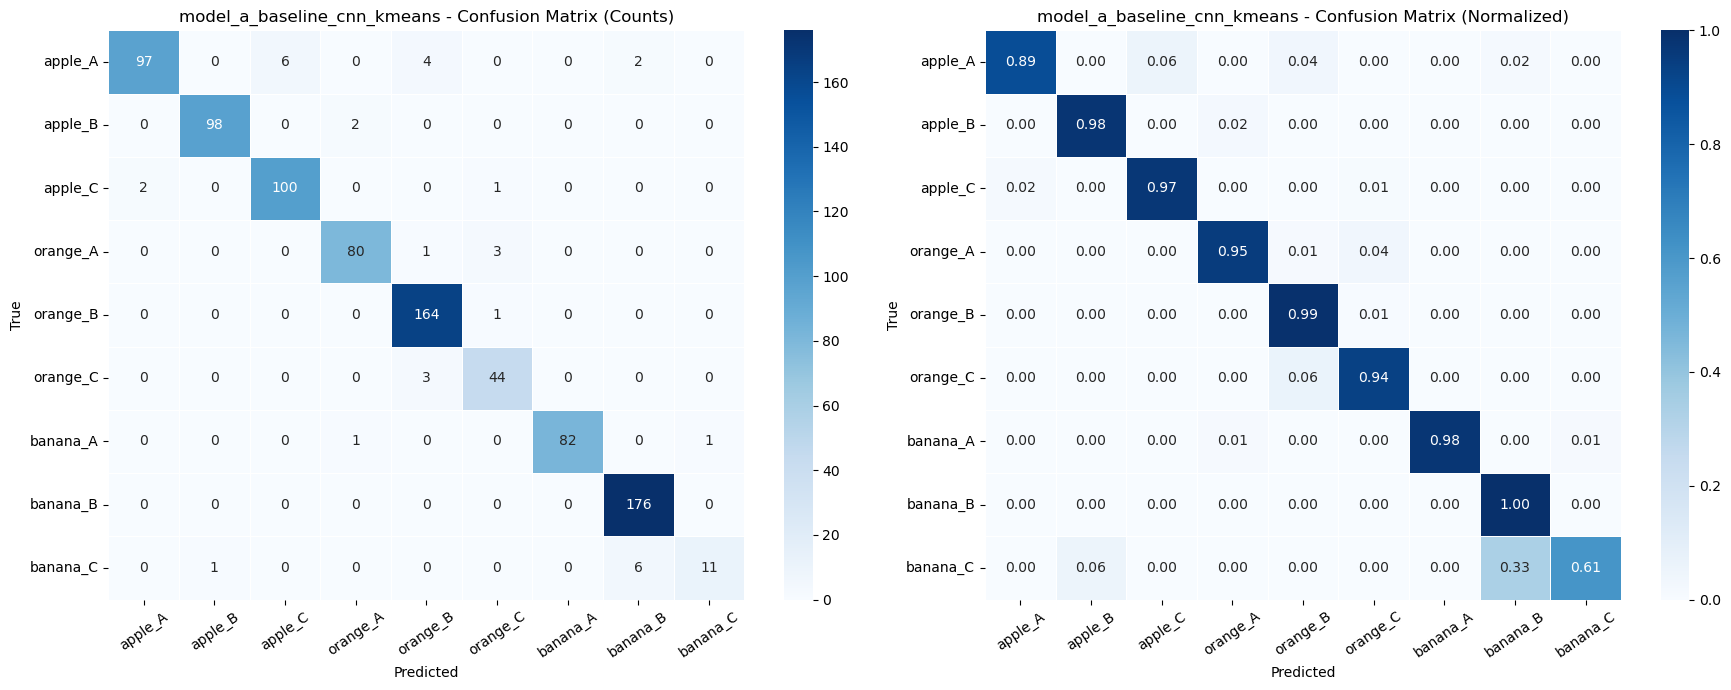

              precision    recall  f1-score   support

     apple_A       0.98      0.89      0.93       109
     apple_B       0.99      0.98      0.98       100
     apple_C       0.94      0.97      0.96       103
    orange_A       0.96      0.95      0.96        84
    orange_B       0.95      0.99      0.97       165
    orange_C       0.90      0.94      0.92        47
    banana_A       1.00      0.98      0.99        84
    banana_B       0.96      1.00      0.98       176
    banana_C       0.92      0.61      0.73        18

    accuracy                           0.96       886
   macro avg       0.96      0.92      0.94       886
weighted avg       0.96      0.96      0.96       886


Running model_b_improved_cnn_kmeans: BatchNorm, Dropout, L2, EarlyStopping, ReduceLROnPlateau, augmentasi kuat.
Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.6551 - loss: 1.1462 - precision: 0.7144 - recall: 0.5766 
Epoch 1: val_loss improved from None to 3.85650, saving mo

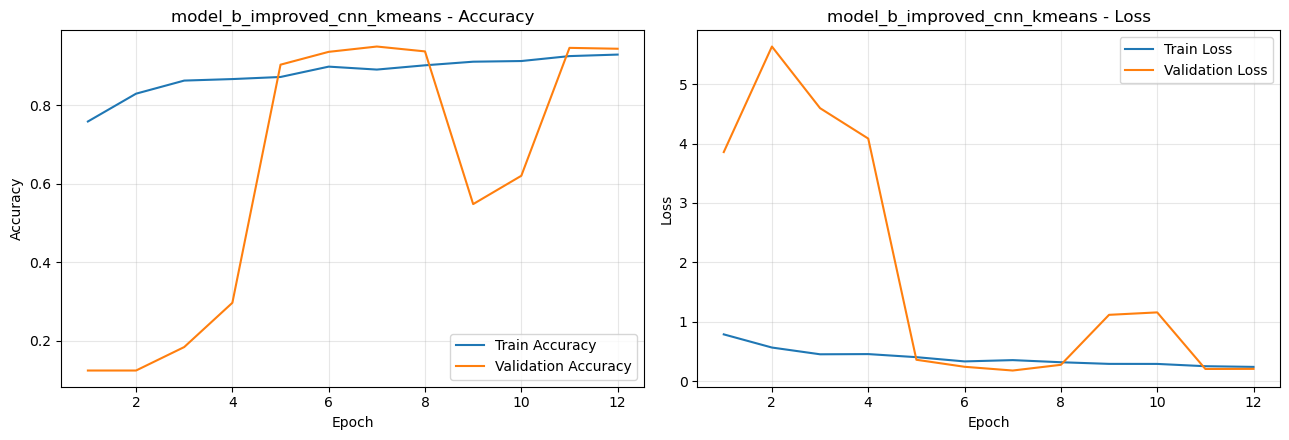

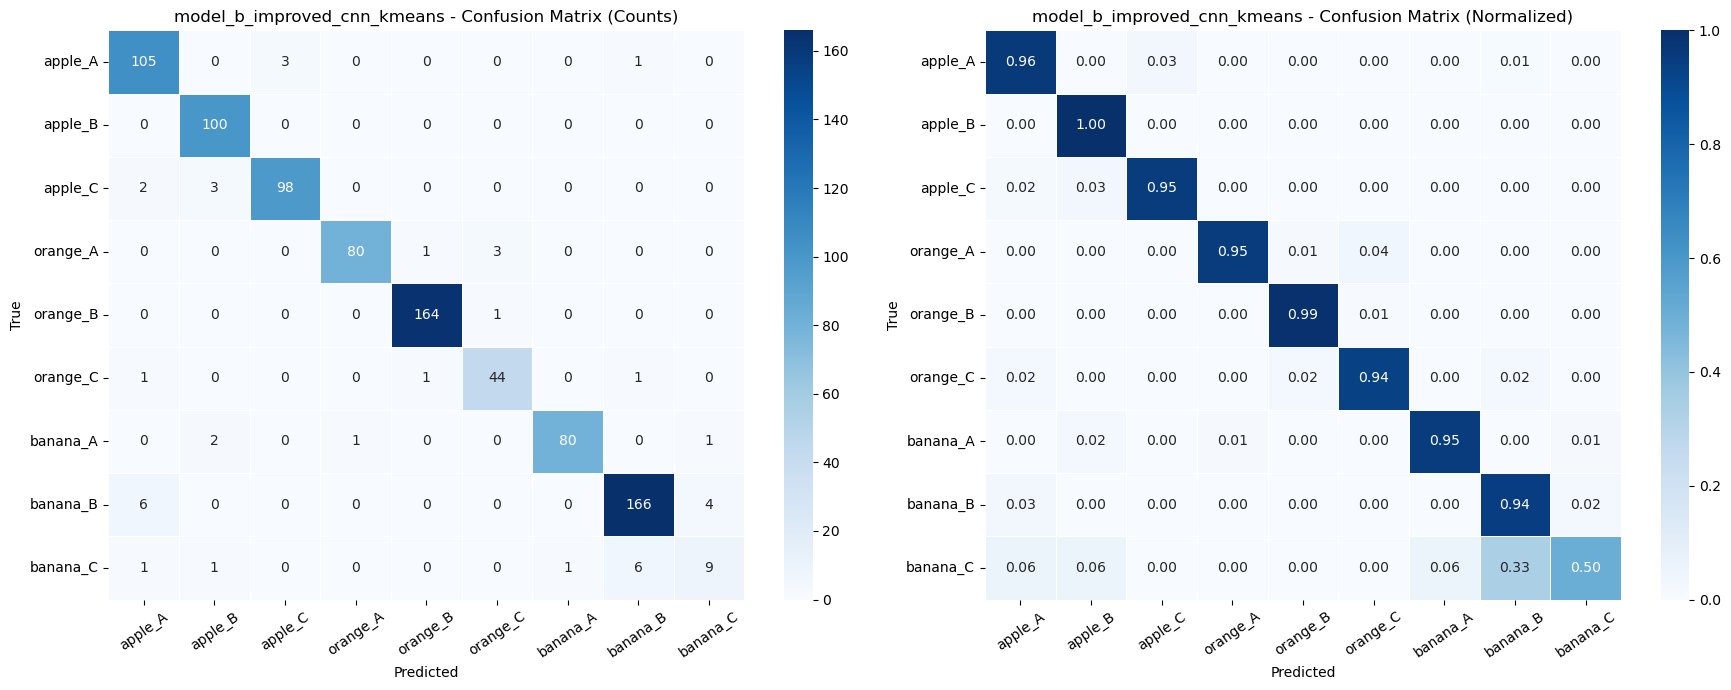

              precision    recall  f1-score   support

     apple_A       0.91      0.96      0.94       109
     apple_B       0.94      1.00      0.97       100
     apple_C       0.97      0.95      0.96       103
    orange_A       0.99      0.95      0.97        84
    orange_B       0.99      0.99      0.99       165
    orange_C       0.92      0.94      0.93        47
    banana_A       0.99      0.95      0.97        84
    banana_B       0.95      0.94      0.95       176
    banana_C       0.64      0.50      0.56        18

    accuracy                           0.95       886
   macro avg       0.92      0.91      0.92       886
weighted avg       0.95      0.95      0.95       886


Running model_c_transfer_mobilenetv2_kmeans: Frozen ImageNet backbone followed by top-layer fine tuning.
Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6340 - loss: 1.1973 - precision: 0.6806 - recall: 0.5866
Epoch 1: val_loss improved from None to 0.45122, saving model to ou

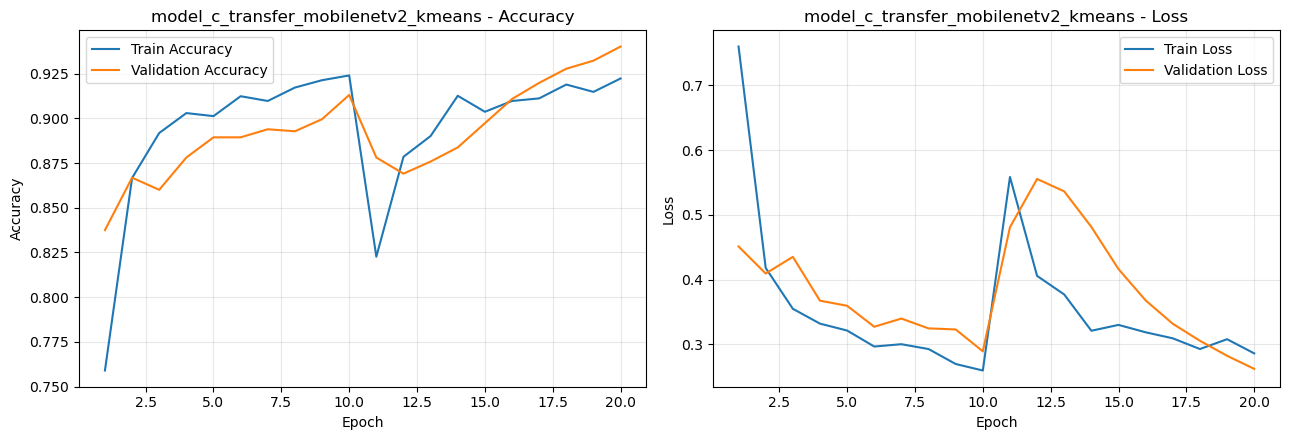

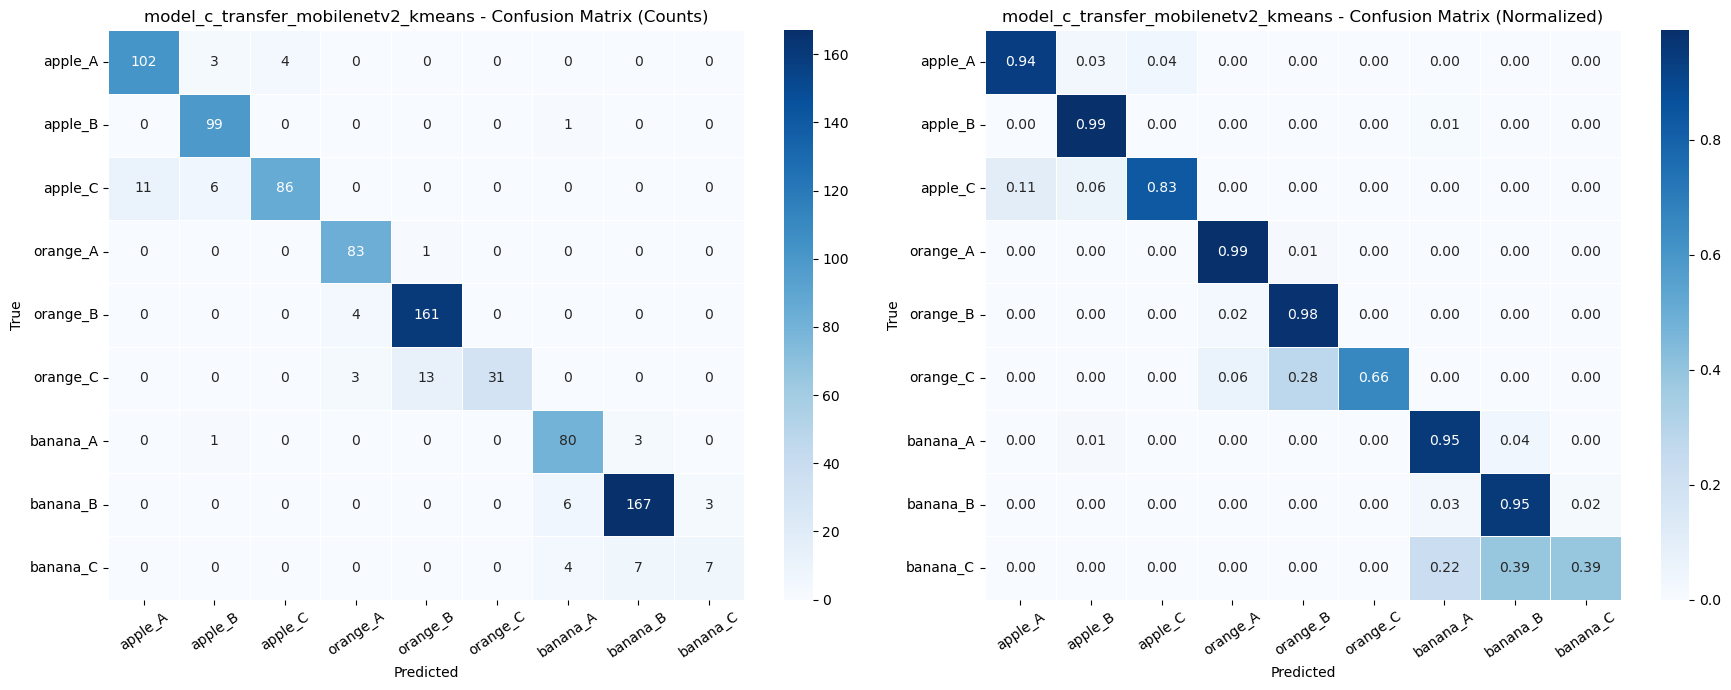

              precision    recall  f1-score   support

     apple_A       0.90      0.94      0.92       109
     apple_B       0.91      0.99      0.95       100
     apple_C       0.96      0.83      0.89       103
    orange_A       0.92      0.99      0.95        84
    orange_B       0.92      0.98      0.95       165
    orange_C       1.00      0.66      0.79        47
    banana_A       0.88      0.95      0.91        84
    banana_B       0.94      0.95      0.95       176
    banana_C       0.70      0.39      0.50        18

    accuracy                           0.92       886
   macro avg       0.90      0.85      0.87       886
weighted avg       0.92      0.92      0.92       886


Running model_e_baseline_cnn_gmm: Alternative clustering GMM per fruit, lalu CNN baseline.
Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3138 - loss: 1.8430 - precision: 0.4870 - recall: 0.0863
Epoch 1: val_loss improved from None to 0.72056, saving model to output/comparati

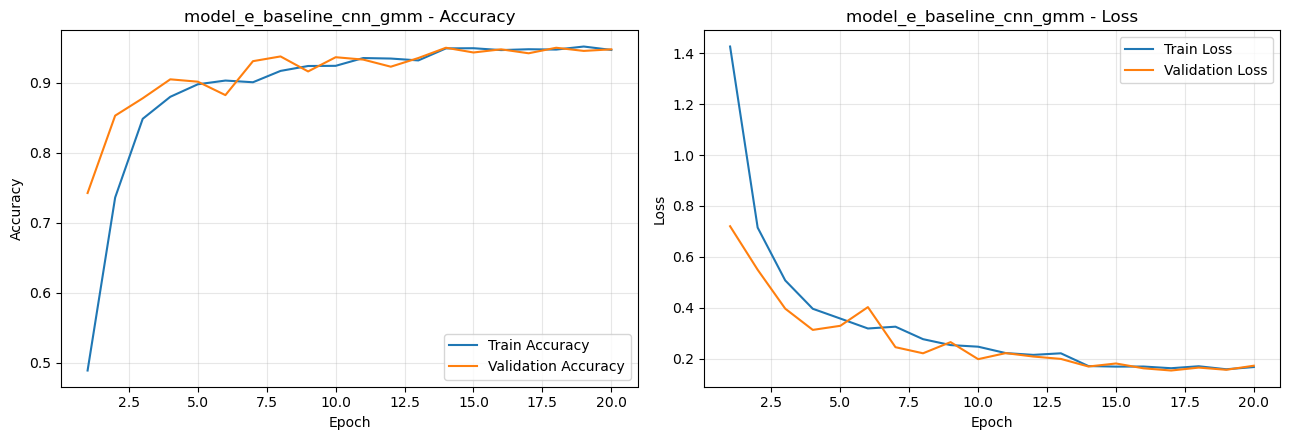

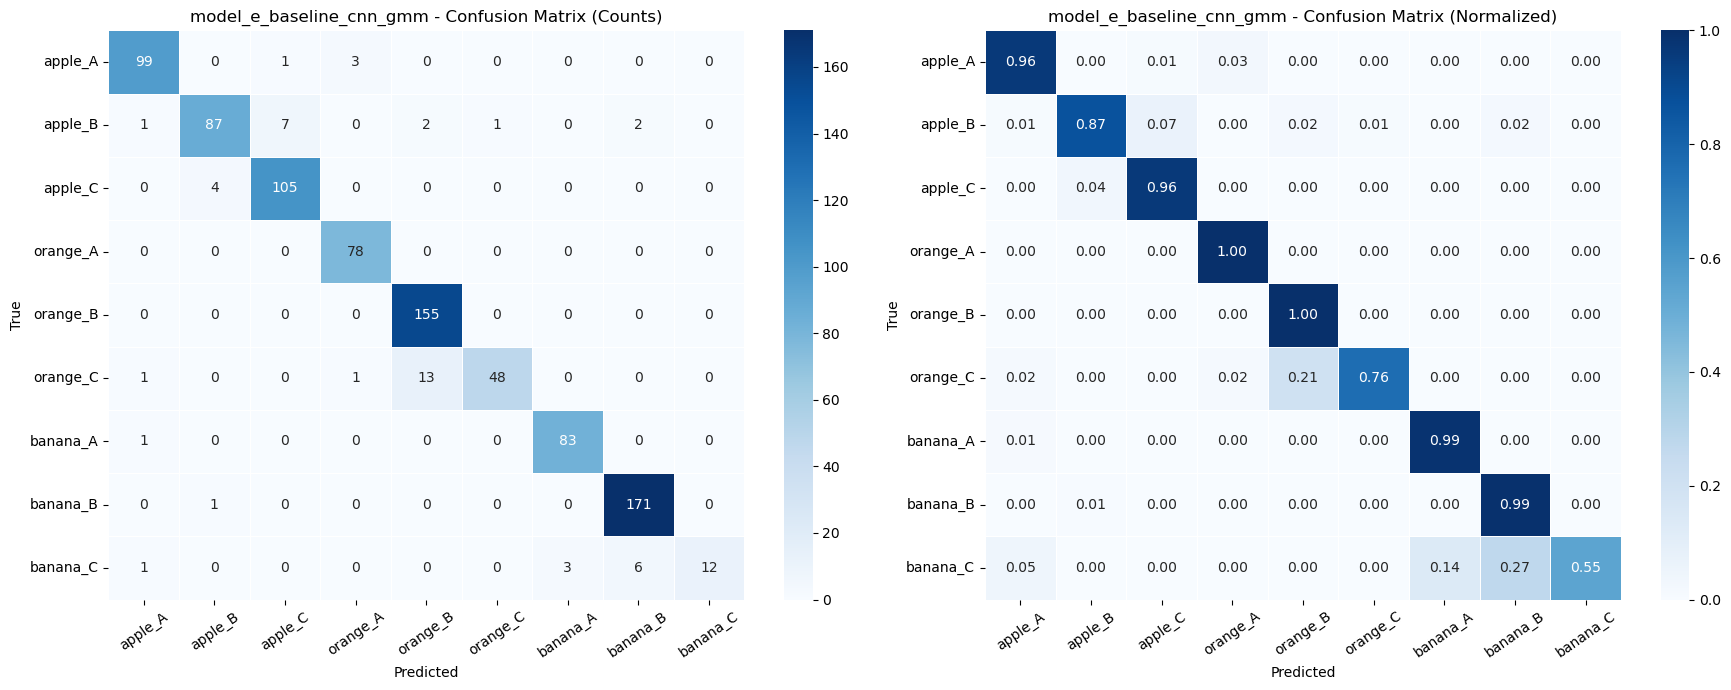

              precision    recall  f1-score   support

     apple_A       0.96      0.96      0.96       103
     apple_B       0.95      0.87      0.91       100
     apple_C       0.93      0.96      0.95       109
    orange_A       0.95      1.00      0.97        78
    orange_B       0.91      1.00      0.95       155
    orange_C       0.98      0.76      0.86        63
    banana_A       0.97      0.99      0.98        84
    banana_B       0.96      0.99      0.97       172
    banana_C       1.00      0.55      0.71        22

    accuracy                           0.95       886
   macro avg       0.96      0.90      0.92       886
weighted avg       0.95      0.95      0.94       886



In [11]:
all_results = []

experiments = [
    (
        ExperimentSpec(
            name="model_a_baseline_cnn_kmeans",
            label_source="KMeans pseudo-label",
            build_kind="Baseline CNN",
            notes="CNN sederhana dengan augmentasi ringan sebagai baseline.",
        ),
        df_kmeans,
        lambda n: build_baseline_cnn(n, augmentation="light"),
    ),
    (
        ExperimentSpec(
            name="model_b_improved_cnn_kmeans",
            label_source="KMeans pseudo-label",
            build_kind="Improved CNN",
            notes="BatchNorm, Dropout, L2, EarlyStopping, ReduceLROnPlateau, augmentasi kuat.",
        ),
        df_kmeans,
        lambda n: build_improved_cnn(n, augmentation="strong"),
    ),
]

for spec, label_df, build_fn in experiments:
    try:
        all_results.append(train_standard_experiment(spec, label_df, build_fn))
    except Exception as exc:
        print(f"SKIPPED/FAILED {spec.name}: {exc}")

try:
    all_results.append(train_transfer_experiment(df_kmeans))
except Exception as exc:
    print(f"SKIPPED/FAILED model_c_transfer_mobilenetv2_kmeans: {exc}")

if df_manual is not None:
    spec = ExperimentSpec(
        name="model_d_improved_cnn_manual_labels",
        label_source=f"Manual/original label: {manual_label_path}",
        build_kind="Improved CNN",
        notes="Tanpa KMeans; memakai label manual/original jika tersedia.",
    )
    try:
        all_results.append(train_standard_experiment(spec, df_manual, lambda n: build_improved_cnn(n, augmentation="strong")))
    except Exception as exc:
        print(f"SKIPPED/FAILED {spec.name}: {exc}")
else:
    all_results.append(
        {
            "experiment": "model_d_improved_cnn_manual_labels",
            "label_source": "Manual/original label",
            "model_type": "Improved CNN",
            "notes": "Skipped: manual/original label file tidak tersedia.",
            "accuracy": np.nan,
            "precision_macro": np.nan,
            "recall_macro": np.nan,
            "f1_macro": np.nan,
            "best_epoch": np.nan,
            "best_train_accuracy": np.nan,
            "best_val_accuracy": np.nan,
            "accuracy_gap": np.nan,
            "loss_gap": np.nan,
            "overfitting_status": "Skipped",
            "n_train": np.nan,
            "n_val": np.nan,
            "n_test": np.nan,
        }
    )

spec = ExperimentSpec(
    name="model_e_baseline_cnn_gmm",
    label_source="GMM pseudo-label",
    build_kind="Baseline CNN",
    notes="Alternative clustering GMM per fruit, lalu CNN baseline.",
)
try:
    all_results.append(train_standard_experiment(spec, df_gmm, lambda n: build_baseline_cnn(n, augmentation="light")))
except Exception as exc:
    print(f"SKIPPED/FAILED {spec.name}: {exc}")

## 10. Tabel Komparasi dan Analisis Otomatis

In [12]:
results_df = pd.DataFrame(all_results)

metric_cols = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "best_val_accuracy",
    "accuracy_gap",
    "loss_gap",
]
for col in metric_cols:
    if col in results_df.columns:
        results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

results_path = OUTPUT_DIR / "comparison_results.csv"
results_df.to_csv(results_path, index=False)

display_cols = [
    "experiment",
    "label_source",
    "model_type",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "best_val_accuracy",
    "accuracy_gap",
    "overfitting_status",
    "notes",
]
display(results_df[display_cols].sort_values("f1_macro", ascending=False, na_position="last"))
print(f"Saved comparison table -> {results_path}")

,experiment,label_source,model_type,accuracy,precision_macro,recall_macro,f1_macro,best_val_accuracy,accuracy_gap,overfitting_status,notes
0,model_a_baseline_cnn_kmeans,KMeans pseudo-label,Baseline CNN,0.961625,0.955732,0.923397,0.935740,0.957111,-0.004303,Stable / low gap,CNN sederhana dengan augmentasi ringan sebagai...
4,model_e_baseline_cnn_gmm,GMM pseudo-label,Baseline CNN,0.945824,0.955447,0.898234,0.917340,0.950339,-0.000919,Stable / low gap,"Alternative clustering GMM per fruit, lalu CNN..."
1,model_b_improved_cnn_kmeans,KMeans pseudo-label,Improved CNN,0.954853,0.922616,0.910312,0.915208,0.950339,-0.058761,Stable / low gap,"BatchNorm, Dropout, L2, EarlyStopping, ReduceL..."
2,model_c_transfer_mobilenetv2_kmeans,KMeans pseudo-label,MobileNetV2 transfer learning,0.920993,0.903479,0.852699,0.868210,0.940181,-0.017867,Stable / low gap,Frozen ImageNet backbone followed by top-layer...
3,model_d_improved_cnn_manual_labels,Manual/original label,Improved CNN,NaN,NaN,NaN,NaN,NaN,NaN,Skipped,Skipped: manual/original label file tidak ters...


Saved comparison table -> output/comparative_experiments/comparison_results.csv


In [13]:
valid_results = results_df.dropna(subset=["f1_macro"]).copy()

if valid_results.empty:
    print("Belum ada hasil training valid. Jalankan sel eksperimen setelah dataset tersedia.")
else:
    best = valid_results.sort_values(["f1_macro", "accuracy"], ascending=False).iloc[0]
    most_stable = valid_results.sort_values(["accuracy_gap", "loss_gap"], ascending=True).iloc[0]
    most_overfit = valid_results.sort_values(["accuracy_gap", "loss_gap"], ascending=False).iloc[0]

    print("=" * 70)
    print("ANALISIS KOMPARASI OTOMATIS")
    print("=" * 70)
    print(f"Model terbaik berdasarkan F1 macro: {best['experiment']} (F1={best['f1_macro']:.4f}, Acc={best['accuracy']:.4f})")
    print(f"Model paling stabil: {most_stable['experiment']} (accuracy gap={most_stable['accuracy_gap']:.4f})")
    print(f"Model paling overfit: {most_overfit['experiment']} (accuracy gap={most_overfit['accuracy_gap']:.4f})")

    kmeans_rows = valid_results[valid_results["label_source"].str.contains("KMeans", na=False)]
    gmm_rows = valid_results[valid_results["label_source"].str.contains("GMM", na=False)]
    manual_rows = valid_results[valid_results["label_source"].str.contains("Manual|original", case=False, na=False)]
    transfer_rows = valid_results[valid_results["model_type"].str.contains("transfer", case=False, na=False)]
    cnn_rows = valid_results[~valid_results["model_type"].str.contains("transfer", case=False, na=False)]

    if not transfer_rows.empty and not cnn_rows.empty:
        best_transfer = transfer_rows["f1_macro"].max()
        best_cnn = cnn_rows[cnn_rows["label_source"].str.contains("KMeans|GMM", na=False)]["f1_macro"].max()
        print(f"Transfer learning {'membantu' if best_transfer > best_cnn else 'belum mengungguli CNN'} pada run ini: best transfer F1={best_transfer:.4f}, best non-transfer F1={best_cnn:.4f}.")

    if not kmeans_rows.empty and not gmm_rows.empty:
        print(f"Dampak clustering alternatif: best KMeans F1={kmeans_rows['f1_macro'].max():.4f}, best GMM F1={gmm_rows['f1_macro'].max():.4f}.")

    if not manual_rows.empty:
        print(f"Tanpa KMeans/manual label: best manual/original F1={manual_rows['f1_macro'].max():.4f}. Bandingkan dengan pseudo-label untuk menilai pengaruh kualitas label.")
    else:
        print("Model D belum bisa dianalisis karena label manual/original tidak tersedia.")

ANALISIS KOMPARASI OTOMATIS
Model terbaik berdasarkan F1 macro: model_a_baseline_cnn_kmeans (F1=0.9357, Acc=0.9616)
Model paling stabil: model_b_improved_cnn_kmeans (accuracy gap=-0.0588)
Model paling overfit: model_e_baseline_cnn_gmm (accuracy gap=-0.0009)
Transfer learning belum mengungguli CNN pada run ini: best transfer F1=0.8682, best non-transfer F1=0.9357.
Dampak clustering alternatif: best KMeans F1=0.9357, best GMM F1=0.9173.
Model D belum bisa dianalisis karena label manual/original tidak tersedia.


## Catatan Interpretasi

- Jika semua model punya validation/test performance rendah, kemungkinan besar masalah ada pada kualitas pseudo-label atau sinyal visual grade yang memang lemah.
- Jika CNN kecil jauh lebih stabil daripada model besar, overfitting lebih mungkin berasal dari kapasitas arsitektur.
- Jika Transfer Learning membaik di validation tetapi tidak di test, cek augmentasi, label noise, dan split per kelas.
- Jika GMM lebih baik dari KMeans, label pseudo dari clustering utama layak dievaluasi ulang lewat `output/cluster_samples/` dan `output/boundary_review/`.
- Jika Model D tersedia dan jauh lebih baik dari pseudo-label, masalah utama kemungkinan kualitas label KMeans, bukan arsitektur CNN.